In [4]:
!rm -rf ~/.cache/huggingface/hub/models--jingang--TabICL

In [5]:
!pip install -q hf_transfer


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [6]:
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"   # turbo HF downloads

In [7]:
!pip install -q tabicl


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [8]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from sklearn.model_selection import train_test_split

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("PyTorch:", torch.__version__, "| device:", device)

from tabicl import TabICLClassifier
print("TabICL imported OK")

PyTorch: 2.12.0 | device: mps
TabICL imported OK


/Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd/.venv/lib/python3.13/site-packages/huggingface_hub/constants.py:298: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [9]:
from pathlib import Path
import pandas as pd

# Known repo root (confirmed earlier); fall back to an upward search if it ever moves
PROJECT_ROOT = Path("/Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd")
IBM_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-HR-Employee-Attrition.csv"

if not IBM_PATH.exists():
    for base in [Path.cwd(), *Path.cwd().parents]:
        p = base / "data" / "raw" / "WA_Fn-UseC_-HR-Employee-Attrition.csv"
        if p.exists():
            PROJECT_ROOT, IBM_PATH = base, p
            break

assert IBM_PATH.exists(), f"IBM CSV not found. cwd={Path.cwd()}"
print("Using:", IBM_PATH)

df = pd.read_csv(IBM_PATH)
df = df.drop(columns=['EmployeeCount','Over18','StandardHours','EmployeeNumber'])
y  = (df['Attrition'] == 'Yes').astype(int)
df = df.drop(columns=['Attrition'])
df['OverTime'] = (df['OverTime'] == 'Yes').astype(int)

wellbeing_vars = ['JobSatisfaction','EnvironmentSatisfaction','RelationshipSatisfaction','WorkLifeBalance']
df['WellbeingIndex'] = df[wellbeing_vars].mean(axis=1)

print("Features:", df.shape, "| positives:", int(y.sum()), f"({y.mean():.1%})")

Using: /Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd/data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv
Features: (1470, 31) | positives: 237 (16.1%)


In [10]:
# Encoded view for LR/XGB (one-hot); raw view for TabICL (native categorical handling)
cat_cols = df.select_dtypes(include='object').columns.tolist()
X_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
X_raw = df.copy()   # TabICL ordinal-encodes categoricals internally

# Reproduce the locked split (identical rows to notebook 05): stratified 80/20, seed 42
idx_train, idx_test = train_test_split(df.index, test_size=0.20, random_state=42, stratify=y)

Xtr_enc, Xte_enc = X_enc.loc[idx_train], X_enc.loc[idx_test]
Xtr_raw, Xte_raw = X_raw.loc[idx_train], X_raw.loc[idx_test]
ytr, yte = y.loc[idx_train], y.loc[idx_test]

print(f"Train: {len(idx_train)} | Test: {len(idx_test)}")
print(f"Train positives: {ytr.mean():.3f} | Test positives: {yte.mean():.3f}")
print(f"Encoded features: {X_enc.shape[1]} | Raw features: {X_raw.shape[1]} | categoricals: {cat_cols}")

Train: 1176 | Test: 294
Train positives: 0.162 | Test positives: 0.160
Encoded features: 45 | Raw features: 31 | categoricals: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


/var/folders/hn/prhcc8bj7l76vbmwf98w5hs80000gn/T/ipykernel_5137/740797621.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score

# --- Logistic Regression (locked primary) ---
lr = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42)),
])
lr.fit(Xtr_enc, ytr)
p_lr = lr.predict_proba(Xte_enc)[:, 1]

# --- XGBoost tuned (exact best params from notebook 06) ---
imbalance_ratio = (ytr == 0).sum() / (ytr == 1).sum()
xgb = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.6, colsample_bytree=1.0, min_child_weight=1, gamma=0.2,
        scale_pos_weight=imbalance_ratio, random_state=42,
        eval_metric='auc', verbosity=0,
        device='cpu', tree_method='hist', nthread=1)),
])
xgb.fit(Xtr_enc, ytr)
p_xgb = xgb.predict_proba(Xte_enc)[:, 1]

def report(name, p, thr=0.5):
    pred = (p >= thr).astype(int)
    print(f"{name:22s} AUC={roc_auc_score(yte, p):.4f}  recall={recall_score(yte, pred):.2f}  "
          f"precision={precision_score(yte, pred):.2f}  F1={f1_score(yte, pred):.2f}")

print("Reproduced locked baselines (target: LR AUC 0.8226, XGB AUC 0.7786):\n")
report("Logistic Regression", p_lr)
report("XGBoost (tuned)", p_xgb)

Reproduced locked baselines (target: LR AUC 0.8226, XGB AUC 0.7786):

Logistic Regression    AUC=0.8226  recall=0.34  precision=0.62  F1=0.44
XGBoost (tuned)        AUC=0.7786  recall=0.40  precision=0.53  F1=0.46


In [12]:
tab = pd.read_csv(PROJECT_ROOT/"data"/"processed"/"tabicl_test_probs.csv").set_index("row_index")
p_tab = tab.loc[idx_test, "p_tabicl"].values
report("Logistic Regression", p_lr)
report("XGBoost (tuned)", p_xgb)
report("TabICL", p_tab)

Logistic Regression    AUC=0.8226  recall=0.34  precision=0.62  F1=0.44
XGBoost (tuned)        AUC=0.7786  recall=0.40  precision=0.53  F1=0.46
TabICL                 AUC=0.8390  recall=0.45  precision=0.75  F1=0.56


              Model  ROC_AUC  Recall  Precision   F1 Leavers_Caught  False_Alarms
Logistic Regression   0.8226    0.34       0.62 0.44          16/47            10
    XGBoost (tuned)   0.7786    0.40       0.53 0.46          19/47            17
             TabICL   0.8390    0.45       0.75 0.56          21/47             7


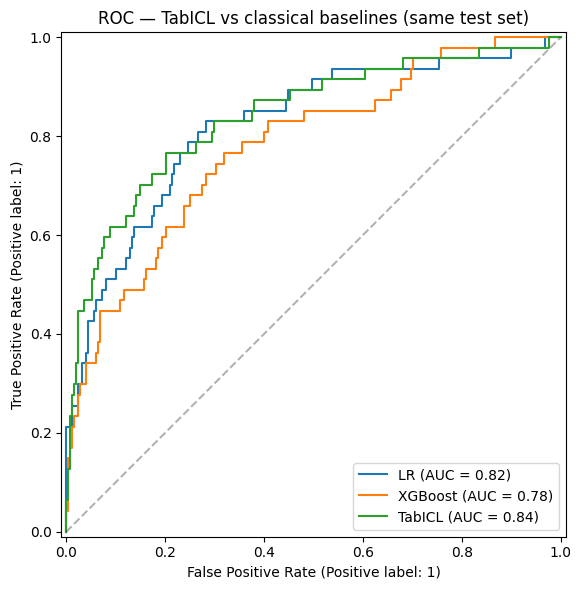

In [13]:
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                             f1_score, confusion_matrix, RocCurveDisplay)

def row(name, p, thr=0.5):
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
    return {'Model': name,
            'ROC_AUC':   round(roc_auc_score(yte, p), 4),
            'Recall':    round(recall_score(yte, pred), 2),
            'Precision': round(precision_score(yte, pred), 2),
            'F1':        round(f1_score(yte, pred), 2),
            'Leavers_Caught': f"{tp}/{tp+fn}",
            'False_Alarms':   fp}

comp = pd.DataFrame([row("Logistic Regression", p_lr),
                     row("XGBoost (tuned)",     p_xgb),
                     row("TabICL",              p_tab)])
print(comp.to_string(index=False))
(comp.to_csv(PROJECT_ROOT/"outputs"/"tables"/"four_model_comparison.csv", index=False))

# ROC overlay
fig, ax = plt.subplots(figsize=(7, 6))
for name, p in [("LR", p_lr), ("XGBoost", p_xgb), ("TabICL", p_tab)]:
    RocCurveDisplay.from_predictions(yte, p, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title("ROC — TabICL vs classical baselines (same test set)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT/"outputs"/"figures"/"roc_tabicl_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

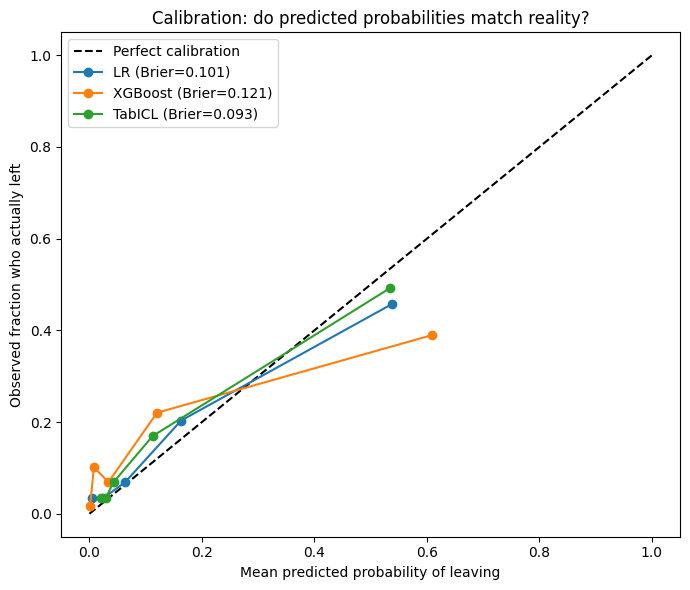

True leave rate in test set: 0.160  <-- average prediction should be near this

Logistic Regression    Brier=0.1010  mean_pred=0.159
XGBoost (tuned)        Brier=0.1213  mean_pred=0.155
TabICL                 Brier=0.0933  mean_pred=0.148


In [14]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
for name, p in [("LR", p_lr), ("XGBoost", p_xgb), ("TabICL", p_tab)]:
    frac_pos, mean_pred = calibration_curve(yte, p, n_bins=5, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o',
            label=f"{name} (Brier={brier_score_loss(yte, p):.3f})")
ax.set_xlabel("Mean predicted probability of leaving")
ax.set_ylabel("Observed fraction who actually left")
ax.set_title("Calibration: do predicted probabilities match reality?")
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT/"outputs"/"figures"/"calibration_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"True leave rate in test set: {yte.mean():.3f}  <-- average prediction should be near this\n")
for name, p in [("Logistic Regression", p_lr), ("XGBoost (tuned)", p_xgb), ("TabICL", p_tab)]:
    print(f"{name:22s} Brier={brier_score_loss(yte, p):.4f}  mean_pred={p.mean():.3f}")

In [15]:
# Local — attach TabICL leaving-probability to the enriched dataset
enr  = pd.read_csv(PROJECT_ROOT/"data"/"processed"/"ibm_enriched.csv")
prob = pd.read_csv(PROJECT_ROOT/"data"/"processed"/"tabicl_oof_probs_all.csv")
enr  = enr.merge(prob[['EmployeeNumber','p_leave_tabicl']], on='EmployeeNumber', how='left')
print("Merged:", enr.shape, "| nulls in prob:", enr['p_leave_tabicl'].isna().sum())
enr.to_csv(PROJECT_ROOT/"data"/"processed"/"ibm_enriched_scored.csv", index=False)
print("Saved ibm_enriched_scored.csv — ready for notebook 09")

Merged: (1470, 47) | nulls in prob: 0
Saved ibm_enriched_scored.csv — ready for notebook 09
